#### Verbindung zu MongoDB herstellen

In [1]:
from pymongo import MongoClient

# Verbindung zum lokalen MongoDB-Server
client = MongoClient('mongodb://localhost:27017/')

# Datenbank auswählen
db = client['meine_datenbank']

# Collection auswählen
collection = db['inventory']

#### Beispieldaten einfügen

In [2]:
from pymongo import MongoClient

client = MongoClient('mongodb://localhost:27017/')
db = client['shop_db']
inventory = db['inventory']

# Alte Daten löschen (für sauberen Start)
inventory.delete_many({})

# Beispieldaten einfügen
dokumente = [
    {
        "item": "journal",
        "qty": 25,
        "size": {"h": 14, "w": 21, "uom": "cm"},
        "status": "A",
        "tags": ["blank", "red"]
    },
    {
        "item": "notebook",
        "qty": 50,
        "size": {"h": 8.5, "w": 11, "uom": "in"},
        "status": "A",
        "tags": ["red", "blank"]
       },
    {
        "item": "paper",
        "qty": 100,
        "size": {"h": 8.5, "w": 11, "uom": "in"},
        "status": "D",
        "tags": ["red", "blank", "plain"]
    },
    {
        "item": "planner",
        "qty": 75,
        "size": {"h": 22.85, "w": 30, "uom": "cm"},
        "status": "D",
        "tags": ["blank", "red"]
    },
    {
        "item": "postcard",
        "qty": 45,
        "size": {"h": 10, "w": 15.25, "uom": "cm"},
        "status": "A",
        "tags": ["blue"]
    }
]

result = inventory.insert_many(dokumente)
print(f"{len(result.inserted_ids)} Dokumente eingefügt")

5 Dokumente eingefügt


##### 2. Alle Dokumente abfragen

In [3]:
# Alle Dokumente finden
alle_dokumente = inventory.find()

# Dokumente durchlaufen und ausgeben
for dok in alle_dokumente:
    print(dok)

{'_id': ObjectId('69da0f2579772cd2f467aa14'), 'item': 'journal', 'qty': 25, 'size': {'h': 14, 'w': 21, 'uom': 'cm'}, 'status': 'A', 'tags': ['blank', 'red']}
{'_id': ObjectId('69da0f2579772cd2f467aa15'), 'item': 'notebook', 'qty': 50, 'size': {'h': 8.5, 'w': 11, 'uom': 'in'}, 'status': 'A', 'tags': ['red', 'blank']}
{'_id': ObjectId('69da0f2579772cd2f467aa16'), 'item': 'paper', 'qty': 100, 'size': {'h': 8.5, 'w': 11, 'uom': 'in'}, 'status': 'D', 'tags': ['red', 'blank', 'plain']}
{'_id': ObjectId('69da0f2579772cd2f467aa17'), 'item': 'planner', 'qty': 75, 'size': {'h': 22.85, 'w': 30, 'uom': 'cm'}, 'status': 'D', 'tags': ['blank', 'red']}
{'_id': ObjectId('69da0f2579772cd2f467aa18'), 'item': 'postcard', 'qty': 45, 'size': {'h': 10, 'w': 15.25, 'uom': 'cm'}, 'status': 'A', 'tags': ['blue']}


Schönere Ausgabe mit pprint:

In [4]:
from pprint import pprint

# Alle Dokumente schön formatiert ausgeben
for dok in inventory.find():
    pprint(dok)
    print("-" * 50)

{'_id': ObjectId('69da0f2579772cd2f467aa14'),
 'item': 'journal',
 'qty': 25,
 'size': {'h': 14, 'uom': 'cm', 'w': 21},
 'status': 'A',
 'tags': ['blank', 'red']}
--------------------------------------------------
{'_id': ObjectId('69da0f2579772cd2f467aa15'),
 'item': 'notebook',
 'qty': 50,
 'size': {'h': 8.5, 'uom': 'in', 'w': 11},
 'status': 'A',
 'tags': ['red', 'blank']}
--------------------------------------------------
{'_id': ObjectId('69da0f2579772cd2f467aa16'),
 'item': 'paper',
 'qty': 100,
 'size': {'h': 8.5, 'uom': 'in', 'w': 11},
 'status': 'D',
 'tags': ['red', 'blank', 'plain']}
--------------------------------------------------
{'_id': ObjectId('69da0f2579772cd2f467aa17'),
 'item': 'planner',
 'qty': 75,
 'size': {'h': 22.85, 'uom': 'cm', 'w': 30},
 'status': 'D',
 'tags': ['blank', 'red']}
--------------------------------------------------
{'_id': ObjectId('69da0f2579772cd2f467aa18'),
 'item': 'postcard',
 'qty': 45,
 'size': {'h': 10, 'uom': 'cm', 'w': 15.25},
 'stat

##### 3. Abfragen mit Bedingungen

Gleicheit

In [5]:
# Abfrage mit Bedingung
ergebnis = inventory.find({"status": "A"})

print("Dokumente mit Status A:")
for dok in ergebnis:
    print(f"- {dok['item']}: Menge {dok['qty']}")

Dokumente mit Status A:
- journal: Menge 25
- notebook: Menge 50
- postcard: Menge 45


Mehrere Bedingungen (AND)

In [6]:
# AND-Bedingung (implizit)
ergebnis = inventory.find({
    "status": "A",
    "qty": {"$lt": 30}
})

print("Status A und Menge < 30:")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['qty']} Stück")

Status A und Menge < 30:
- journal: 25 Stück


##### 4. Vergleichsoperatoren

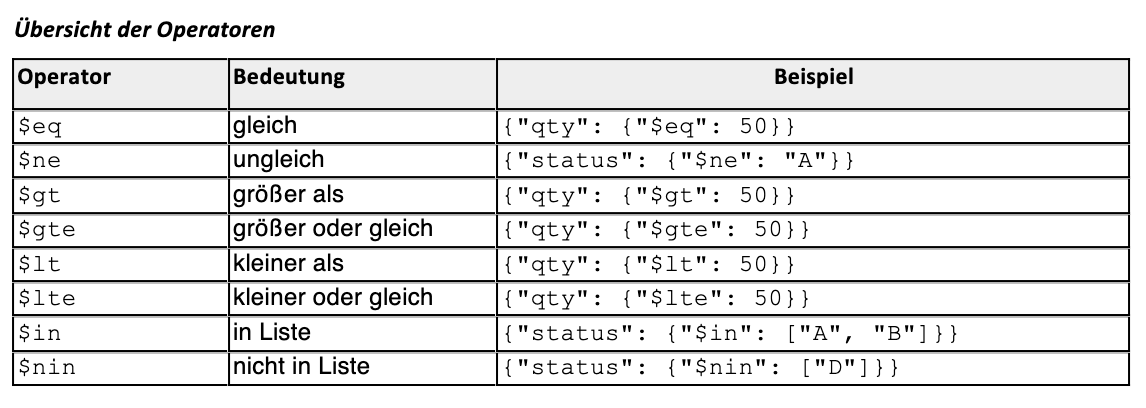

In [6]:
# Menge größer als 50
print("Menge > 50:")
for dok in inventory.find({"qty": {"$gt": 50}}):
    print(f"- {dok['item']}: {dok['qty']}")

print("\n" + "="*50 + "\n")

# Menge zwischen 40 und 80
print("Menge zwischen 40 und 80:")
for dok in inventory.find({
    "qty": {"$gte": 40, "$lte": 80}
}):
    print(f"- {dok['item']}: {dok['qty']}")

print("\n" + "="*50 + "\n")

# Status ist A oder D
print("Status A oder D:")
for dok in inventory.find({
    "status": {"$in": ["A", "D"]}
}):
    print(f"- {dok['item']}: Status {dok['status']}")

Menge > 50:
- paper: 100
- planner: 75


Menge zwischen 40 und 80:
- notebook: 50
- planner: 75
- postcard: 45


Status A oder D:
- journal: Status A
- notebook: Status A
- paper: Status D
- planner: Status D
- postcard: Status A


##### 5. Logische Operatoren (OR, AND, NOT)

OR

In [7]:
# OR-Bedingung
ergebnis = inventory.find({
    "$or": [
        {"status": "A"},
        {"qty": {"$lt": 30}}
    ]
})

print("Status A ODER Menge < 30:")
for dok in ergebnis:
    print(f"- {dok['item']}: Status={dok['status']}, Menge={dok['qty']}")

Status A ODER Menge < 30:
- journal: Status=A, Menge=25
- notebook: Status=A, Menge=50
- postcard: Status=A, Menge=45


AND und OR kombinieren

In [8]:
# Komplexe Abfrage: Status A UND (Menge < 30 ODER item beginnt mit 'p')
ergebnis = inventory.find({
    "status": "A",
    "$or": [
        {"qty": {"$lt": 30}},
        {"item": {"$regex": "^p"}}  # beginnt mit 'p'
    ]
})

print("Status A UND (Menge < 30 ODER item beginnt mit 'p'):")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['qty']}")

Status A UND (Menge < 30 ODER item beginnt mit 'p'):
- journal: 25
- postcard: 45


NOT-Operator

In [9]:
# Alle Dokumente OHNE Status D
ergebnis = inventory.find({
    "status": {"$ne": "D"}
})

print("Alle außer Status D:")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['status']}")


Alle außer Status D:
- journal: A
- notebook: A
- postcard: A


##### 6. Verschachtelte Dokumente abfragen

In [10]:
# Alle Artikel mit Maßeinheit "in" (inches)
ergebnis = inventory.find({"size.uom": "in"})

print("Artikel mit Maßeinheit 'in':")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['size']['h']} x {dok['size']['w']} {dok['size']['uom']}")

Artikel mit Maßeinheit 'in':
- notebook: 8.5 x 11 in
- paper: 8.5 x 11 in


Mehrere Bedingungen auf verschachtelten Feldern

In [11]:
# Höhe < 15 UND Maßeinheit = "cm"
ergebnis = inventory.find({
    "size.h": {"$lt": 15},
    "size.uom": "cm"
})

print("Höhe < 15 cm:")
for dok in ergebnis:
    print(f"- {dok['item']}: Höhe {dok['size']['h']} cm")

Höhe < 15 cm:
- journal: Höhe 14 cm
- postcard: Höhe 10 cm


Exakte Übereinstimmung mit verschachteltem Dokument

In [7]:
# Exakte Übereinstimmung (Reihenfolge der Felder muss stimmen!)
ergebnis = inventory.find({
    "size": {"h": 14, "w": 21, "uom": "cm"}
})

print("Exakte Größe 14x21 cm:")
for dok in ergebnis:
    print(f"- {dok['item']}")


Exakte Größe 14x21 cm:
- journal


##### 7. Arrays abfragen

Array enthält bestimmten Wert

In [13]:
# Alle Artikel mit Tag "red"
ergebnis = inventory.find({"tags": "red"})

print("Artikel mit Tag 'red':")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['tags']}")


Artikel mit Tag 'red':
- journal: ['blank', 'red']
- notebook: ['red', 'blank']
- paper: ['red', 'blank', 'plain']
- planner: ['blank', 'red']


Array enthält alle angegebenen Werte

In [14]:
# Artikel mit BEIDEN Tags: "red" UND "blank"
ergebnis = inventory.find({
    "tags": {"$all": ["red", "blank"]}
})

print("Artikel mit Tags 'red' UND 'blank':")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['tags']}")

Artikel mit Tags 'red' UND 'blank':
- journal: ['blank', 'red']
- notebook: ['red', 'blank']
- paper: ['red', 'blank', 'plain']
- planner: ['blank', 'red']


Exakte Array-Übereinstimmung

In [15]:
# Exakt diese Tags in dieser Reihenfolge
ergebnis = inventory.find({
    "tags": ["blank", "red"]
})

print("Exakt ['blank', 'red']:")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['tags']}")

Exakt ['blank', 'red']:
- journal: ['blank', 'red']
- planner: ['blank', 'red']


Array-Länge abfragen

In [16]:
# Arrays mit genau 3 Elementen
ergebnis = inventory.find({
    "tags": {"$size": 3}
})

print("Artikel mit genau 3 Tags:")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['tags']}")

Artikel mit genau 3 Tags:
- paper: ['red', 'blank', 'plain']


##### 8. Projektion - Felder auswählen

Nur bestimmte Felder zurückgeben

In [10]:
# Nur item und status zurückgeben (+ _id automatisch)
ergebnis = inventory.find(
    {"status": "A"}
    ,{"item": 1, "status": 1}
)

print("Nur item und status:")
for dok in ergebnis:
    print(dok)

Nur item und status:
{'_id': ObjectId('69da0f2579772cd2f467aa14'), 'item': 'journal', 'status': 'A'}
{'_id': ObjectId('69da0f2579772cd2f467aa15'), 'item': 'notebook', 'status': 'A'}
{'_id': ObjectId('69da0f2579772cd2f467aa18'), 'item': 'postcard', 'status': 'A'}


_id ausschließen

In [20]:
# _id nicht zurückgeben
ergebnis = inventory.find(
    {"status": "A"},
    {"item": 1, "qty": 1, "_id": 0}
)

print("Ohne _id:")
for dok in ergebnis:
    print(dok)

Ohne _id:
{'item': 'journal', 'qty': 25}
{'item': 'notebook', 'qty': 50}
{'item': 'postcard', 'qty': 45}


Felder ausschließen

In [21]:
# Alle Felder außer tags und size
ergebnis = inventory.find(
    {},
    {"tags": 0, "size": 0}
)

print("Ohne tags und size:")
for dok in ergebnis:
    pprint(dok)
    print("-" * 30)

Ohne tags und size:
{'_id': ObjectId('69c02a453f53fdc6a7186879'),
 'item': 'journal',
 'qty': 25,
 'status': 'A'}
------------------------------
{'_id': ObjectId('69c02a453f53fdc6a718687a'),
 'item': 'notebook',
 'qty': 50,
 'status': 'A'}
------------------------------
{'_id': ObjectId('69c02a453f53fdc6a718687b'),
 'item': 'paper',
 'qty': 100,
 'status': 'D'}
------------------------------
{'_id': ObjectId('69c02a453f53fdc6a718687c'),
 'item': 'planner',
 'qty': 75,
 'status': 'D'}
------------------------------
{'_id': ObjectId('69c02a453f53fdc6a718687d'),
 'item': 'postcard',
 'qty': 45,
 'status': 'A'}
------------------------------


Verschachtelte Felder in Projektion

In [22]:
# Nur bestimmte Felder aus verschachteltem Dokument
ergebnis = inventory.find(
    {},
    {"item": 1, "size.uom": 1, "_id": 0}
)

print("Item und Maßeinheit:")
for dok in ergebnis:
    print(dok)


Item und Maßeinheit:
{'item': 'journal', 'size': {'uom': 'cm'}}
{'item': 'notebook', 'size': {'uom': 'in'}}
{'item': 'paper', 'size': {'uom': 'in'}}
{'item': 'planner', 'size': {'uom': 'cm'}}
{'item': 'postcard', 'size': {'uom': 'cm'}}


##### 9. Cursor-Methoden

**Einführung zu Cursors**

Die find()-Methode gibt keinen direkten Datensatz zurück, sondern einen Cursor. Ein Cursor ist ein Zeiger auf die Ergebnismenge, der es ermöglicht, durch die Dokumente zu iterieren und verschiedene Operationen anzuwenden.

Sortieren mit sort()

In [23]:
# Nach Menge aufsteigend sortieren (1 = aufsteigend)
ergebnis = inventory.find().sort("qty", 1)

print("Nach Menge aufsteigend sortiert:")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['qty']} Stück")

Nach Menge aufsteigend sortiert:
- journal: 25 Stück
- postcard: 45 Stück
- notebook: 50 Stück
- planner: 75 Stück
- paper: 100 Stück


In [24]:
# Nach Menge absteigend sortieren (-1 = absteigend)
ergebnis = inventory.find().sort("qty", -1)

print("Nach Menge absteigend sortiert:")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['qty']} Stück")

Nach Menge absteigend sortiert:
- paper: 100 Stück
- planner: 75 Stück
- notebook: 50 Stück
- postcard: 45 Stück
- journal: 25 Stück


Alternative Syntax mit pymongo

In [26]:
from pymongo import ASCENDING, DESCENDING

# Aufsteigend
ergebnis = inventory.find().sort("qty", ASCENDING)

print("Mit ASCENDING:")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['qty']}")
    
# Absteigend
ergebnis = inventory.find().sort("qty", DESCENDING)

print("Mit DESCENDING:")
for dok in ergebnis:
    print(f"- {dok['item']}: {dok['qty']}")

Mit ASCENDING:
- journal: 25
- postcard: 45
- notebook: 50
- planner: 75
- paper: 100
Mit DESCENDING:
- paper: 100
- planner: 75
- notebook: 50
- postcard: 45
- journal: 25


Nach mehreren Felder sortieren

In [28]:
# Erst nach status, dann nach qty
ergebnis = inventory.find().sort([
    ("status", ASCENDING),
    ("qty", DESCENDING)
])

print("Nach Status (aufsteigend), dann Menge (absteigend):")
for dok in ergebnis:
    print(f"- {dok['item']}: Status={dok['status']}, Menge={dok['qty']}")

Nach Status (aufsteigend), dann Menge (absteigend):
- notebook: Status=A, Menge=50
- postcard: Status=A, Menge=45
- journal: Status=A, Menge=25
- paper: Status=D, Menge=100
- planner: Status=D, Menge=75
